# Challenge 1: datos y análisis exploratorio

Tu primera responsabilidad es preparar una fuente de datos confiable para el proyecto de clasificación de vinos.

**Entrada:** `data/raw/wine.csv`  
**Salidas:** `data/processed/train.csv`, `data/processed/test.csv` y `artifacts/data_contract.json`

> El conjunto de test se crea aquí, pero no debe explorarse ni utilizarse después del split.

## Objetivos

- cargar y validar datos externos;
- identificar problemas básicos de calidad;
- crear un split reproducible y estratificado;
- realizar EDA únicamente sobre entrenamiento;
- guardar datos y metadatos para la siguiente etapa.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

np.random.seed(42)
plt.rcParams["figure.figsize"] = (7, 4)

In [2]:
from pathlib import Path

PROJECT_DIR = Path.cwd()
RAW_DATA_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"
ARTIFACTS_DIR = PROJECT_DIR / "artifacts"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in (PROCESSED_DATA_DIR, ARTIFACTS_DIR, REPORTS_DIR):
    directory.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

## 1. Carga y profiling

In [3]:
DATA_PATH = RAW_DATA_DIR / "wine.csv"

df = pd.read_csv(DATA_PATH)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [4]:
print("Forma del dataset:", df.shape)
print()
print("Tipos de datos:")
print(df.dtypes)
print()
print("Valores nulos por columna:")
print(df.isnull().sum())
print()
print("Filas duplicadas:", df.duplicated().sum())
print()
print("Distribución de la variable objetivo:")
print(df["target"].value_counts().sort_index())
print()
print("Distribución (proporción):")
print(df["target"].value_counts(normalize=True).sort_index())
print()
df.describe().T

Forma del dataset: (178, 14)

Tipos de datos:
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Valores nulos por columna:
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue         

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


**Conclusión de calidad:**

> El dataset tiene 178 filas y 14 columnas (13 features numéricas de tipo float + `target` entero), sin valores nulos y sin filas duplicadas. Las tres clases están moderadamente desbalanceadas (59 / 71 / 48 instancias, ~33% / 40% / 27%), por lo que el split debe hacerse con `stratify` para conservar esa proporción en train y test. Las escalas de las variables son muy distintas (p. ej. `proline` llega a >1000 mientras `hue` está entre 0 y 2), lo cual se abordará con un `StandardScaler` dentro del pipeline en el challenge 2, no antes.

## 2. Split train/test

In [5]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["target"],
    random_state=RANDOM_STATE,
)

In [6]:
# Verificación del split
assert len(train_df) + len(test_df) == len(df)
assert set(train_df.index).isdisjoint(set(test_df.index))
print("Train:", train_df.shape)
print("Test:", test_df.shape)

Train: (142, 14)
Test: (36, 14)


## 3. EDA sobre entrenamiento

Incluye:

- distribución de clases;
- distribuciones o boxplots de variables relevantes;
- correlaciones;
- tres hallazgos que puedan influir en el modelado.

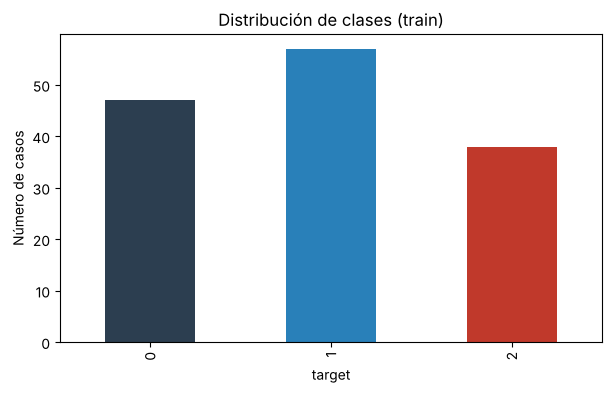

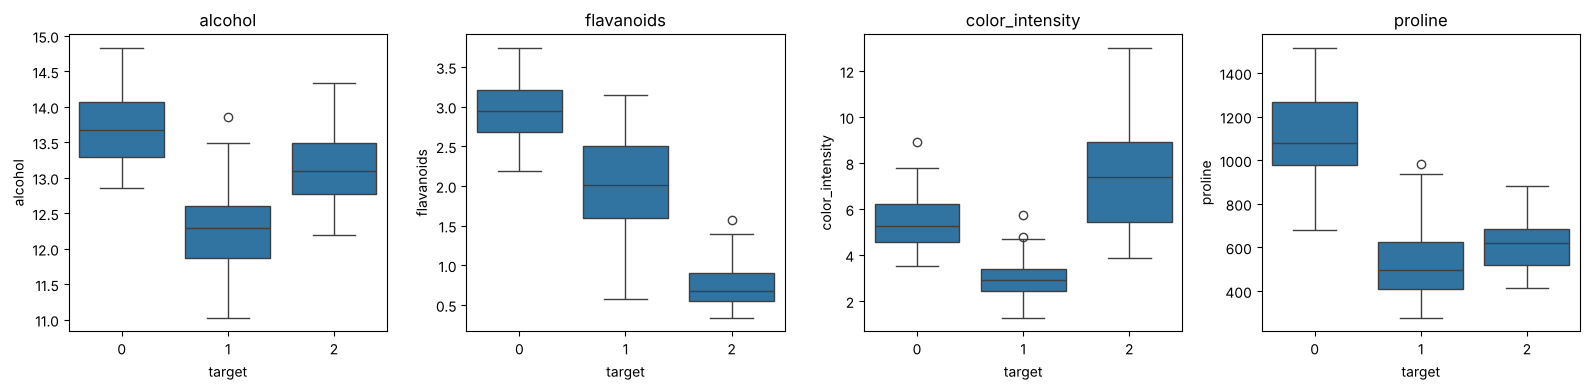

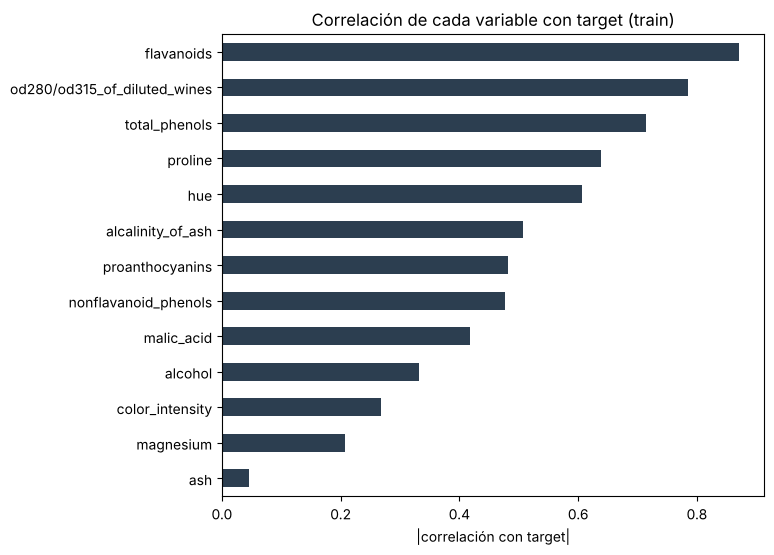

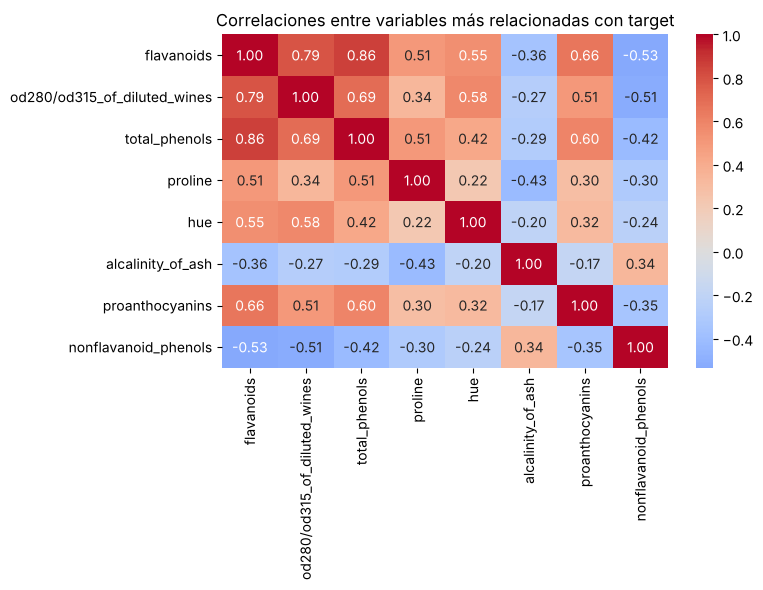

In [7]:
# 1. Distribución de clases en entrenamiento
counts = train_df["target"].value_counts().sort_index()
ax = counts.plot.bar(color=["#2c3e50", "#2980b9", "#c0392b"])
ax.set_xlabel("target")
ax.set_ylabel("Número de casos")
ax.set_title("Distribución de clases (train)")
plt.show()

# 2. Boxplots de variables relevantes por clase
selected = ["alcohol", "flavanoids", "color_intensity", "proline"]
fig, axes = plt.subplots(1, len(selected), figsize=(16, 4))
for ax, col in zip(axes, selected):
    sns.boxplot(data=train_df, x="target", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 3. Correlación de cada variable con el target
correlations = train_df.corr(numeric_only=True)["target"].drop("target").abs().sort_values(ascending=False)
correlations.sort_values().plot.barh(color="#2c3e50", figsize=(7, 6))
plt.xlabel("|correlación con target|")
plt.title("Correlación de cada variable con target (train)")
plt.show()

# 4. Mapa de calor de correlaciones entre las variables más relevantes
top_features = correlations.head(8).index
plt.figure(figsize=(8, 6))
sns.heatmap(train_df[top_features].corr(), cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlaciones entre variables más relacionadas con target")
plt.tight_layout()
plt.show()

**Hallazgos:**

1. `flavanoids` es, por mucho, la variable más correlacionada con `target` (|r| ≈ 0.87 en train), seguida de `od280/od315_of_diluted_wines` (≈0.78) y `total_phenols` (≈0.71); estas tres variables están además correlacionadas entre sí, por lo que probablemente capturan una misma señal química relacionada con el proceso de elaboración del vino.
2. Las clases se separan de forma visible en varias variables: la clase 0 tiene en promedio más `proline` (~1092) y más `flavanoids` (~2.93) que las clases 1 y 2, mientras que la clase 2 tiene el `color_intensity` más alto (~7.4) pero el `flavanoids` más bajo (~0.78). Esto sugiere que un modelo lineal simple ya debería lograr buena separación.
3. Las variables tienen escalas muy distintas (`proline` en cientos/miles vs. `hue` entre 0 y 2), por lo que KNN y regresión logística necesitarán `StandardScaler`; un árbol de decisión, en cambio, es invariante a la escala y solo necesita imputación.

## 4. Persistencia de datos y contrato

In [8]:
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_df.to_csv(PROCESSED_DATA_DIR / "train.csv", index=False)
test_df.to_csv(PROCESSED_DATA_DIR / "test.csv", index=False)

target_column = "target"
feature_columns = [c for c in df.columns if c != target_column]

data_contract = {
    "target": target_column,
    "features": feature_columns,
    "random_state": RANDOM_STATE,
    "test_size": 0.2,
}

(ARTIFACTS_DIR / "data_contract.json").write_text(
    json.dumps(data_contract, indent=2, ensure_ascii=False),
    encoding="utf-8",
)

data_contract

{'target': 'target',
 'features': ['alcohol',
  'malic_acid',
  'ash',
  'alcalinity_of_ash',
  'magnesium',
  'total_phenols',
  'flavanoids',
  'nonflavanoid_phenols',
  'proanthocyanins',
  'color_intensity',
  'hue',
  'od280/od315_of_diluted_wines',
  'proline'],
 'random_state': 42,
 'test_size': 0.2}

In [9]:
# Verificación de entrega
assert (PROCESSED_DATA_DIR / "train.csv").exists()
assert (PROCESSED_DATA_DIR / "test.csv").exists()
assert (ARTIFACTS_DIR / "data_contract.json").exists()
print("Challenge 1 completado.")

Challenge 1 completado.
